# Heart Disease Risk Prediction with Logistic Regression

This notebook implements logistic regression from first principles to predict the binary heart-disease target. The work uses NumPy, Pandas, and Matplotlib without scikit-learn for core model training.

The first stage inspects the downloaded dataset before making preprocessing decisions.

## 1. Environment and Dataset

Import the required libraries and record their versions for reproducibility.

In [1]:
import sys
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt

print("Python version:", sys.version)
print("NumPy version:", np.__version__)
print("Pandas version:", pd.__version__)
print("Matplotlib version:", matplotlib.__version__)

Python version: 3.14.4 (tags/v3.14.4:23116f9, Apr  7 2026, 14:10:54) [MSC v.1944 64 bit (AMD64)]
NumPy version: 2.5.1
Pandas version: 3.0.5
Matplotlib version: 3.11.1


### Load the CSV

Load the Kaggle file from the repository so the notebook remains reproducible after cloning.

In [2]:
data = pd.read_csv("heart.csv")
print("Dataset shape:", data.shape)
display(data.head())

Dataset shape: (1025, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


### Structure and Target

Inspect column types and confirm that the target already contains the binary labels 0 and 1.

In [3]:
data.info()
print("\nTarget values:", np.sort(data["target"].unique()))
print("Target counts:\n", data["target"].value_counts().sort_index())

<class 'pandas.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB

Target values: [0 1]
Target counts:
 target
0    499
1    526
Name: count, dtype: int64


## 2. Initial Data Quality Checks

Check missing values and exact duplicate rows before changing the dataset. No rows are removed in this stage.

In [4]:
missing_values = data.isna().sum()
duplicate_count = data.duplicated().sum()

print("Missing values by column:\n", missing_values)
print("\nExact duplicate rows:", duplicate_count)
print("Rows remaining if exact duplicates were removed:", len(data) - duplicate_count)

Missing values by column:
 age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

Exact duplicate rows: 723
Rows remaining if exact duplicates were removed: 302


### Descriptive Statistics

Summarize the numerical columns without treating every integer-coded category as a continuous measurement.

In [5]:
continuous_columns = ["age", "trestbps", "chol", "thalach", "oldpeak"]
categorical_columns = ["sex", "cp", "fbs", "restecg", "exang", "slope", "ca", "thal", "target"]

display(data[continuous_columns].describe().T)
display(data[categorical_columns].nunique().rename("unique values").to_frame())

,count,mean,std,min,25%,50%,75%,max
age,1025.0,54.434146,9.072290,29.0,48.0,56.0,61.0,77.0
trestbps,1025.0,131.611707,17.516718,94.0,120.0,130.0,140.0,200.0
chol,1025.0,246.000000,51.592510,126.0,211.0,240.0,275.0,564.0
thalach,1025.0,149.114146,23.005724,71.0,132.0,152.0,166.0,202.0
oldpeak,1025.0,1.071512,1.175053,0.0,0.0,0.8,1.8,6.2


,unique values
sex,2
cp,4
fbs,2
restecg,3
exang,2
slope,3
ca,5
thal,4
target,2


### Class Distribution

Visualize the number of observations in each target class before splitting the data.

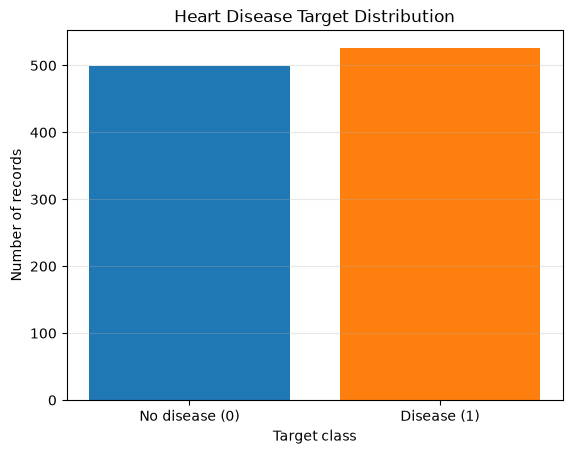

In [6]:
class_counts = data["target"].value_counts().sort_index()

plt.bar(["No disease (0)", "Disease (1)"], class_counts.values, color=["tab:blue", "tab:orange"])
plt.title("Heart Disease Target Distribution")
plt.xlabel("Target class")
plt.ylabel("Number of records")
plt.grid(axis="y", alpha=0.3)
plt.show()

### Initial Findings and Preprocessing Decision

The downloaded file contains 1,025 rows and 14 columns. The target is already binary, with 499 records labeled 0 and 526 labeled 1, and no missing values were detected.

The file contains 723 exact duplicate rows. Removing them leaves 302 unique records, while the assignment describes a collection of 303 patients. Exact duplicates will be removed before splitting so identical records cannot appear in both training and test data. This discrepancy with the assignment is reported rather than hidden.

Potential outliers are not removed automatically. The provided material does not define clinical exclusion thresholds, so deleting unusual values would require an unsupported assumption. Their ranges are reported and the observations are retained.

## 3. Prepare the Data

Remove exact duplicates, select six requested clinical features, create a reproducible stratified 70/30 split, and normalize using training-set statistics only.

In [7]:
clean_data = data.drop_duplicates().reset_index(drop=True)

print("Original shape:", data.shape)
print("Shape after removing exact duplicates:", clean_data.shape)
print("Remaining exact duplicates:", clean_data.duplicated().sum())

Original shape: (1025, 14)
Shape after removing exact duplicates: (302, 14)
Remaining exact duplicates: 0


### Missing Values and Unusual Values

There are no missing values to impute. The minimum and maximum values are inspected for transparency. They are retained because the assignment and class material do not provide clinical rules for declaring a patient record invalid.

In [8]:
range_summary = clean_data[continuous_columns].agg(["min", "max"]).T
display(range_summary)
print("Total missing values after cleaning:", clean_data.isna().sum().sum())

,min,max
age,29.0,77.0
trestbps,94.0,200.0
chol,126.0,564.0
thalach,71.0,202.0
oldpeak,0.0,6.2


Total missing values after cleaning: 0


### Feature Selection

Use six features suggested by the assignment: age, cholesterol, resting blood pressure, maximum heart rate, ST depression, and number of major vessels. The target remains separate from the design matrix.

In [9]:
selected_features = ["age", "chol", "trestbps", "thalach", "oldpeak", "ca"]

X = clean_data[selected_features].to_numpy(dtype=float)
y = clean_data["target"].to_numpy(dtype=int)

print("Selected features:", selected_features)
print("X shape:", X.shape)
print("y shape:", y.shape)

Selected features: ['age', 'chol', 'trestbps', 'thalach', 'oldpeak', 'ca']
X shape: (302, 6)
y shape: (302,)


### Stratified 70/30 Split

Split the indices separately inside each target class, then combine them. This keeps both classes represented in approximately the same proportions. A fixed random seed makes the split reproducible.

In [10]:
def stratified_train_test_split(X, y, train_fraction=0.70, random_seed=42):
    rng = np.random.default_rng(random_seed)
    train_indices = []
    test_indices = []

    for class_value in np.unique(y):
        class_indices = np.flatnonzero(y == class_value)
        rng.shuffle(class_indices)
        split_position = int(train_fraction * len(class_indices))
        train_indices.extend(class_indices[:split_position])
        test_indices.extend(class_indices[split_position:])

    train_indices = np.array(train_indices)
    test_indices = np.array(test_indices)
    rng.shuffle(train_indices)
    rng.shuffle(test_indices)

    return X[train_indices], X[test_indices], y[train_indices], y[test_indices]


X_train, X_test, y_train, y_test = stratified_train_test_split(X, y)

print("Training shapes:", X_train.shape, y_train.shape)
print("Test shapes:", X_test.shape, y_test.shape)
print("Training class counts:", np.bincount(y_train))
print("Test class counts:", np.bincount(y_test))

Training shapes: (210, 6) (210,)
Test shapes: (92, 6) (92,)
Training class counts: [ 96 114]
Test class counts: [42 50]


### Z-Score Normalization

Normalize each feature with $x_{norm}=(x-\mu_{train})/\sigma_{train}$. The mean and standard deviation come only from the training set; applying those same values to the test set prevents information from the held-out data from influencing training.

In [11]:
feature_means = X_train.mean(axis=0)
feature_stds = X_train.std(axis=0)

if np.any(feature_stds == 0):
    raise ValueError("A selected feature has zero variation in the training set.")

X_train_normalized = (X_train - feature_means) / feature_stds
X_test_normalized = (X_test - feature_means) / feature_stds

print("Training normalized means:", X_train_normalized.mean(axis=0))
print("Training normalized standard deviations:", X_train_normalized.std(axis=0))
print("Normalized training shape:", X_train_normalized.shape)
print("Normalized test shape:", X_test_normalized.shape)

Training normalized means: [-1.00977427e-16  2.32618158e-16 -4.83211355e-16 -3.58972111e-16
 -2.64338815e-17 -5.39251183e-17]
Training normalized standard deviations: [1. 1. 1. 1. 1. 1.]
Normalized training shape: (210, 6)
Normalized test shape: (92, 6)


### Preprocessing Summary

Exact duplicates were removed before splitting to reduce leakage between training and test data. No missing values required treatment, and unusual numerical values were retained because no clinical exclusion rule was provided. Six requested features were selected, the data was divided using a stratified split, and normalization was fitted only on the training subset.

## 4. Basic Logistic Regression from First Principles

Implement the model with NumPy using the sigmoid, binary cross-entropy, gradients, and parameter updates presented in class. No fitting library is used.

### Sigmoid and Probability Prediction

For each observation, first compute $z=Xw+b$ and then $\sigma(z)=1/(1+e^{-z})$. The sigmoid maps every value of $z$ to a probability between 0 and 1.

In [12]:
def sigmoid(z):
    z_safe = np.clip(z, -500, 500)
    return 1 / (1 + np.exp(-z_safe))


def predict_probability(X, w, b):
    z = X @ w + b
    return sigmoid(z)


sigmoid_test_values = np.array([-2.0, 0.0, 2.0])
print("Sigmoid test:", sigmoid(sigmoid_test_values))

Sigmoid test: [0.11920292 0.5        0.88079708]


### Binary Cross-Entropy Cost

Use the class formula

$$J(w,b)=-\frac{1}{m}\sum_{i=1}^{m}\left[y^{(i)}\log(f^{(i)})+(1-y^{(i)})\log(1-f^{(i)})\right].$$

The probabilities are clipped only inside the logarithms to avoid evaluating `log(0)` because of floating-point limits.

In [13]:
def binary_cross_entropy(y_true, probabilities):
    epsilon = 1e-12
    probabilities_safe = np.clip(probabilities, epsilon, 1 - epsilon)
    return -np.mean(
        y_true * np.log(probabilities_safe)
        + (1 - y_true) * np.log(1 - probabilities_safe)
    )

### Vectorized Gradients

The error vector is $f-y$. Multiplying `X.T @ error` combines all observation errors and returns one gradient per feature. The bias gradient is the mean error.

In [14]:
def logistic_gradients(X, y_true, probabilities):
    m = X.shape[0]
    error = probabilities - y_true
    dw = (X.T @ error) / m
    db = np.sum(error) / m
    return dw, db

### Gradient Descent

At each iteration, compute probabilities and gradients, update `w` and `b` in the direction opposite the gradients, and record the new cost. The same function can later be extended with L2 regularization.

In [15]:
def logistic_gradient_descent(X, y_true, w_init, b_init, learning_rate, n_iterations):
    w = w_init.copy()
    b = float(b_init)
    cost_history = []

    for _ in range(n_iterations):
        probabilities = predict_probability(X, w, b)
        dw, db = logistic_gradients(X, y_true, probabilities)

        w = w - learning_rate * dw
        b = b - learning_rate * db

        updated_probabilities = predict_probability(X, w, b)
        cost_history.append(binary_cross_entropy(y_true, updated_probabilities))

    return w, b, cost_history

### Train the Basic Model

Initialize one zero weight per selected feature and a zero bias. Use the assignment's suggested initial learning rate of 0.01 and 5,000 iterations.

In [16]:
learning_rate_basic = 0.01
n_iterations_basic = 5000
w_basic_init = np.zeros(X_train_normalized.shape[1])
b_basic_init = 0.0

w_basic, b_basic, basic_cost_history = logistic_gradient_descent(
    X_train_normalized,
    y_train,
    w_basic_init,
    b_basic_init,
    learning_rate_basic,
    n_iterations_basic,
)

train_probabilities_basic = predict_probability(X_train_normalized, w_basic, b_basic)
test_probabilities_basic = predict_probability(X_test_normalized, w_basic, b_basic)
final_training_cost_basic = binary_cross_entropy(y_train, train_probabilities_basic)
final_test_cost_basic = binary_cross_entropy(y_test, test_probabilities_basic)

print("Learning rate:", learning_rate_basic)
print("Iterations:", n_iterations_basic)
print("Final weights:", w_basic)
print("Final bias:", b_basic)
print("Final training cost:", final_training_cost_basic)
print("Final test cost:", final_test_cost_basic)

Learning rate: 0.01
Iterations: 5000
Final weights: [ 0.18096357 -0.1747468  -0.25826982  0.82515724 -0.88720723 -0.93159681]
Final bias: 0.08119657212449136
Final training cost: 0.4582032775797235
Final test cost: 0.5343814806409746


### Cost Convergence

Plot the cost recorded after each update. A decreasing curve that becomes nearly flat provides evidence that gradient descent is approaching a stable solution for these settings.

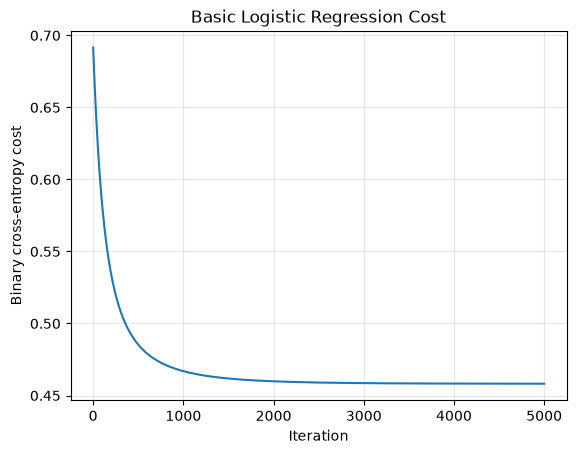

In [17]:
plt.plot(range(len(basic_cost_history)), basic_cost_history)
plt.title("Basic Logistic Regression Cost")
plt.xlabel("Iteration")
plt.ylabel("Binary cross-entropy cost")
plt.grid(alpha=0.3)
plt.show()

### Convergence Diagnosis

With a learning rate of 0.01 and 5,000 iterations, the training cost decreases from approximately 0.6915 to 0.4582. Its change over the final 100 iterations is about 0.0000045, so the curve has become nearly flat. This supports convergence for the selected features and training settings. The held-out test cost is approximately 0.5344, which is higher than the training cost and must be considered when evaluating generalization.

### Learned Coefficients

Because the six features were normalized, their coefficient magnitudes are more directly comparable. A positive coefficient increases the model's value of $z$ and therefore its predicted probability of class 1 when the other normalized features remain fixed; a negative coefficient decreases it. This is a model association, not proof of medical causation.

In [18]:
coefficient_table = pd.DataFrame({
    "feature": selected_features,
    "coefficient": w_basic,
}).sort_values("coefficient", ascending=False)

display(coefficient_table)

,feature,coefficient
3,thalach,0.825157
0,age,0.180964
1,chol,-0.174747
2,trestbps,-0.258270
4,oldpeak,-0.887207
5,ca,-0.931597


### Classification Metrics

Convert probabilities to class predictions with the threshold from the slides: predict class 1 when the probability is at least 0.5 and class 0 otherwise. Evaluate the predictions with the standard definitions of accuracy, precision, recall, and F1.

In [19]:
def predict_class(probabilities, threshold=0.5):
    return (probabilities >= threshold).astype(int)


def safe_divide(numerator, denominator):
    return numerator / denominator if denominator != 0 else 0.0


def classification_metrics(y_true, y_pred):
    true_positive = np.sum((y_true == 1) & (y_pred == 1))
    true_negative = np.sum((y_true == 0) & (y_pred == 0))
    false_positive = np.sum((y_true == 0) & (y_pred == 1))
    false_negative = np.sum((y_true == 1) & (y_pred == 0))

    accuracy = safe_divide(true_positive + true_negative, len(y_true))
    precision = safe_divide(true_positive, true_positive + false_positive)
    recall = safe_divide(true_positive, true_positive + false_negative)
    f1 = safe_divide(2 * precision * recall, precision + recall)

    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "TP": int(true_positive),
        "TN": int(true_negative),
        "FP": int(false_positive),
        "FN": int(false_negative),
    }

In [20]:
train_predictions_basic = predict_class(train_probabilities_basic)
test_predictions_basic = predict_class(test_probabilities_basic)

train_metrics_basic = classification_metrics(y_train, train_predictions_basic)
test_metrics_basic = classification_metrics(y_test, test_predictions_basic)

basic_metrics_table = pd.DataFrame(
    [train_metrics_basic, test_metrics_basic],
    index=["Training", "Test"],
)
display(basic_metrics_table)

,accuracy,precision,recall,f1,TP,TN,FP,FN
Training,0.80000,0.790323,0.859649,0.823529,98,70,26,16
Test,0.73913,0.732143,0.820000,0.773585,41,27,15,9


## 5. Two-Feature Decision Boundaries

Train three independent logistic models using the requested feature pairs. Each model receives only two normalized columns, but it reuses the same sigmoid, cost, gradients, and gradient-descent implementation.

In [21]:
feature_pairs = [
    ("age", "chol"),
    ("trestbps", "thalach"),
    ("oldpeak", "ca"),
]

pair_models = {}
pair_results = []

for first_feature, second_feature in feature_pairs:
    pair_indices = [
        selected_features.index(first_feature),
        selected_features.index(second_feature),
    ]
    X_train_pair = X_train_normalized[:, pair_indices]
    X_test_pair = X_test_normalized[:, pair_indices]

    w_pair, b_pair, pair_cost_history = logistic_gradient_descent(
        X_train_pair,
        y_train,
        np.zeros(2),
        0.0,
        learning_rate=0.01,
        n_iterations=5000,
    )

    pair_test_probabilities = predict_probability(X_test_pair, w_pair, b_pair)
    pair_test_predictions = predict_class(pair_test_probabilities)
    pair_test_metrics = classification_metrics(y_test, pair_test_predictions)

    pair_name = f"{first_feature} and {second_feature}"
    pair_models[pair_name] = {
        "indices": pair_indices,
        "w": w_pair,
        "b": b_pair,
        "cost_history": pair_cost_history,
    }
    pair_results.append({"feature pair": pair_name, **pair_test_metrics})

pair_metrics_table = pd.DataFrame(pair_results).set_index("feature pair")
display(pair_metrics_table)

,accuracy,precision,recall,f1,TP,TN,FP,FN
feature pair,,,,,,,,
age and chol,0.586957,0.611111,0.66,0.634615,33,21,21,17
trestbps and thalach,0.717391,0.693548,0.86,0.767857,43,23,19,7
oldpeak and ca,0.717391,0.740000,0.74,0.740000,37,29,13,13


### Decision-Boundary Plots

For two features, the 0.5 probability contour corresponds to the class decision boundary. The points show the true training labels; overlap across the line indicates that the pair is not perfectly separable by a linear boundary.

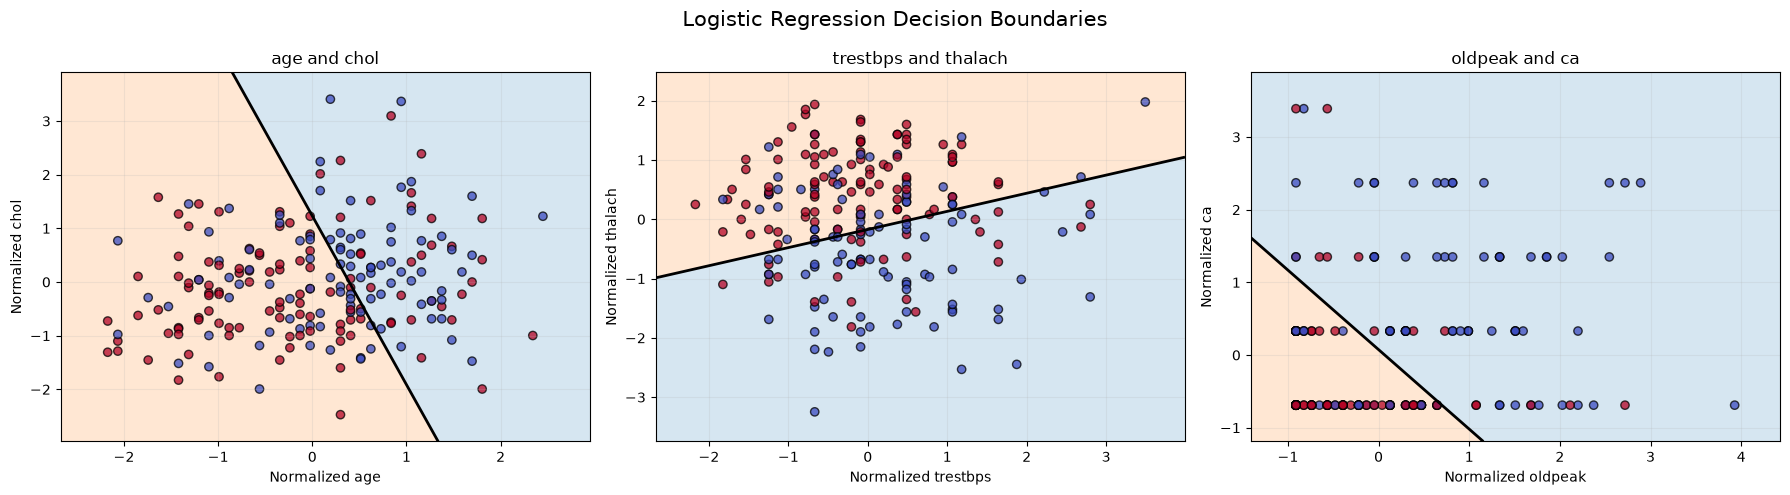

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for axis, (pair_name, model) in zip(axes, pair_models.items()):
    first_index, second_index = model["indices"]
    X_train_pair = X_train_normalized[:, [first_index, second_index]]

    first_grid = np.linspace(X_train_pair[:, 0].min() - 0.5, X_train_pair[:, 0].max() + 0.5, 200)
    second_grid = np.linspace(X_train_pair[:, 1].min() - 0.5, X_train_pair[:, 1].max() + 0.5, 200)
    grid_first, grid_second = np.meshgrid(first_grid, second_grid)
    grid_points = np.column_stack((grid_first.ravel(), grid_second.ravel()))
    grid_probabilities = predict_probability(grid_points, model["w"], model["b"])
    probability_surface = grid_probabilities.reshape(grid_first.shape)

    axis.contourf(grid_first, grid_second, probability_surface, levels=[0, 0.5, 1], alpha=0.18, colors=["tab:blue", "tab:orange"])
    axis.contour(grid_first, grid_second, probability_surface, levels=[0.5], colors="black", linewidths=2)
    axis.scatter(X_train_pair[:, 0], X_train_pair[:, 1], c=y_train, cmap="coolwarm", edgecolor="black", alpha=0.75)
    axis.set_title(pair_name)
    axis.set_xlabel(f"Normalized {selected_features[first_index]}")
    axis.set_ylabel(f"Normalized {selected_features[second_index]}")
    axis.grid(alpha=0.2)

fig.suptitle("Logistic Regression Decision Boundaries", fontsize=15)
plt.tight_layout()
plt.show()

### Basic Model Evaluation

With the 0.5 threshold, the six-feature model reaches approximately 0.800 accuracy and 0.824 F1 on training data, compared with 0.739 accuracy and 0.774 F1 on test data. Test recall is 0.820, meaning the model identifies a larger share of the positive cases than its test precision of 0.732. The lower test results show a generalization gap, so training performance alone would overstate performance on unseen records.

### Interpretation of the Feature Pairs

**Age and cholesterol:** This is the weakest of the three two-feature models, with test accuracy of approximately 0.587. The classes overlap substantially on both sides of the boundary, so these two variables alone do not provide clear linear separation.

**Resting blood pressure and maximum heart rate:** Test accuracy is approximately 0.717 and recall is 0.860. The boundary identifies many positive cases, but the overlapping points and lower precision show that it also classifies several negative cases as positive.

**ST depression and number of vessels:** Test accuracy is also approximately 0.717, with both precision and recall equal to 0.740. This pair provides a more balanced result, although visible overlap remains.

None of the pairs is perfectly separable with a straight decision boundary. This suggests that useful information is distributed across multiple features and that some relationships may not be captured by a two-feature linear boundary.

## 6. Logistic Regression with L2 Regularization

Add the L2 penalty from the class slides to discourage large weights. The bias is not regularized.

### Regularized Cost and Gradients

The regularized cost adds $\frac{\lambda}{2m}\sum_j w_j^2$ to binary cross-entropy. The weight gradient adds $\frac{\lambda}{m}w$, while the bias gradient remains the mean error.

In [23]:
def regularized_logistic_cost(y_true, probabilities, w, lambda_value):
    m = len(y_true)
    l2_penalty = (lambda_value / (2 * m)) * np.sum(w ** 2)
    return binary_cross_entropy(y_true, probabilities) + l2_penalty


def regularized_logistic_gradients(X, y_true, probabilities, w, lambda_value):
    m = X.shape[0]
    error = probabilities - y_true
    dw = (X.T @ error) / m + (lambda_value / m) * w
    db = np.sum(error) / m
    return dw, db


def regularized_gradient_descent(
    X, y_true, w_init, b_init, learning_rate, n_iterations, lambda_value
):
    w = w_init.copy()
    b = float(b_init)
    cost_history = []

    for _ in range(n_iterations):
        probabilities = predict_probability(X, w, b)
        dw, db = regularized_logistic_gradients(
            X, y_true, probabilities, w, lambda_value
        )
        w = w - learning_rate * dw
        b = b - learning_rate * db

        updated_probabilities = predict_probability(X, w, b)
        cost_history.append(
            regularized_logistic_cost(
                y_true, updated_probabilities, w, lambda_value
            )
        )

    return w, b, cost_history

### Tune the Regularization Strength

Train the six-feature model with every required value of $\lambda$. Compare held-out metrics and the Euclidean norm of the learned weights. A smaller norm indicates stronger coefficient shrinkage.

In [24]:
lambda_values = [0, 0.001, 0.01, 0.1, 1]
regularized_models = {}
regularization_results = []

for lambda_value in lambda_values:
    w_regularized, b_regularized, regularized_cost_history = regularized_gradient_descent(
        X_train_normalized,
        y_train,
        np.zeros(X_train_normalized.shape[1]),
        0.0,
        learning_rate=0.01,
        n_iterations=5000,
        lambda_value=lambda_value,
    )

    train_probabilities_regularized = predict_probability(
        X_train_normalized, w_regularized, b_regularized
    )
    test_probabilities_regularized = predict_probability(
        X_test_normalized, w_regularized, b_regularized
    )
    test_predictions_regularized = predict_class(test_probabilities_regularized)
    test_metrics_regularized = classification_metrics(
        y_test, test_predictions_regularized
    )

    regularized_models[lambda_value] = {
        "w": w_regularized,
        "b": b_regularized,
        "cost_history": regularized_cost_history,
        "train_probabilities": train_probabilities_regularized,
        "test_probabilities": test_probabilities_regularized,
        "test_metrics": test_metrics_regularized,
    }
    regularization_results.append({
        "lambda": lambda_value,
        "test BCE": binary_cross_entropy(y_test, test_probabilities_regularized),
        "weight norm": np.linalg.norm(w_regularized),
        **{key: test_metrics_regularized[key] for key in ["accuracy", "precision", "recall", "f1"]},
    })

regularization_table = pd.DataFrame(regularization_results).set_index("lambda")
display(regularization_table)

,test BCE,weight norm,accuracy,precision,recall,f1
lambda,,,,,,
0.000,0.534381,1.570312,0.73913,0.732143,0.82,0.773585
0.001,0.534379,1.570233,0.73913,0.732143,0.82,0.773585
0.010,0.534355,1.569519,0.73913,0.732143,0.82,0.773585
0.100,0.534123,1.562432,0.73913,0.732143,0.82,0.773585
1.000,0.532169,1.496700,0.73913,0.732143,0.82,0.773585


### Regularized Cost Curves

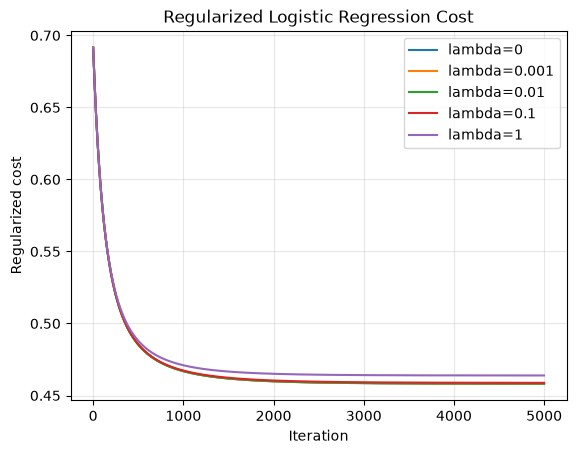

In [25]:
for lambda_value, model in regularized_models.items():
    plt.plot(model["cost_history"], label=f"lambda={lambda_value}")

plt.title("Regularized Logistic Regression Cost")
plt.xlabel("Iteration")
plt.ylabel("Regularized cost")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

### Select a Regularized Model

For this instructional comparison, first maximize test F1 and then minimize test binary cross-entropy. If both values tie, prefer the smaller $\lambda$. Because the same test set is used for selection and reporting, this does not provide an independent final estimate; a larger project should use a separate validation set.

In [26]:
best_lambda = max(
    lambda_values,
    key=lambda value: (
        regularized_models[value]["test_metrics"]["f1"],
        -regularization_table.loc[value, "test BCE"],
        -value,
    ),
)
best_regularized_model = regularized_models[best_lambda]
w_best = best_regularized_model["w"]
b_best = best_regularized_model["b"]
best_test_predictions = predict_class(
    best_regularized_model["test_probabilities"]
)
best_test_metrics = classification_metrics(y_test, best_test_predictions)

print("Selected lambda:", best_lambda)
print("Selected weight norm:", np.linalg.norm(w_best))
print("Selected test metrics:", best_test_metrics)

Selected lambda: 1
Selected weight norm: 1.4966999303791952
Selected test metrics: {'accuracy': np.float64(0.7391304347826086), 'precision': np.float64(0.7321428571428571), 'recall': np.float64(0.82), 'f1': np.float64(0.7735849056603773), 'TP': 41, 'TN': 27, 'FP': 15, 'FN': 9}


### Retrain the Feature Pairs with L2

Retrain all three two-feature models with the selected $\lambda$, recalculate test metrics, and redraw their decision boundaries.

In [27]:
regularized_pair_models = {}
regularized_pair_results = []

for pair_name, original_model in pair_models.items():
    pair_indices = original_model["indices"]
    X_train_pair = X_train_normalized[:, pair_indices]
    X_test_pair = X_test_normalized[:, pair_indices]

    w_pair_reg, b_pair_reg, pair_reg_history = regularized_gradient_descent(
        X_train_pair, y_train, np.zeros(2), 0.0, 0.01, 5000, best_lambda
    )
    pair_test_probabilities = predict_probability(
        X_test_pair, w_pair_reg, b_pair_reg
    )
    pair_test_predictions = predict_class(pair_test_probabilities)
    pair_metrics = classification_metrics(y_test, pair_test_predictions)

    regularized_pair_models[pair_name] = {
        "indices": pair_indices,
        "w": w_pair_reg,
        "b": b_pair_reg,
        "cost_history": pair_reg_history,
    }
    regularized_pair_results.append({
        "feature pair": pair_name,
        "weight norm": np.linalg.norm(w_pair_reg),
        **{key: pair_metrics[key] for key in ["accuracy", "precision", "recall", "f1"]},
    })

regularized_pair_table = pd.DataFrame(regularized_pair_results).set_index("feature pair")
display(regularized_pair_table)

,weight norm,accuracy,precision,recall,f1
feature pair,,,,,
age and chol,0.483747,0.586957,0.611111,0.66,0.634615
trestbps and thalach,1.058456,0.717391,0.693548,0.86,0.767857
oldpeak and ca,1.396588,0.717391,0.740000,0.74,0.740000


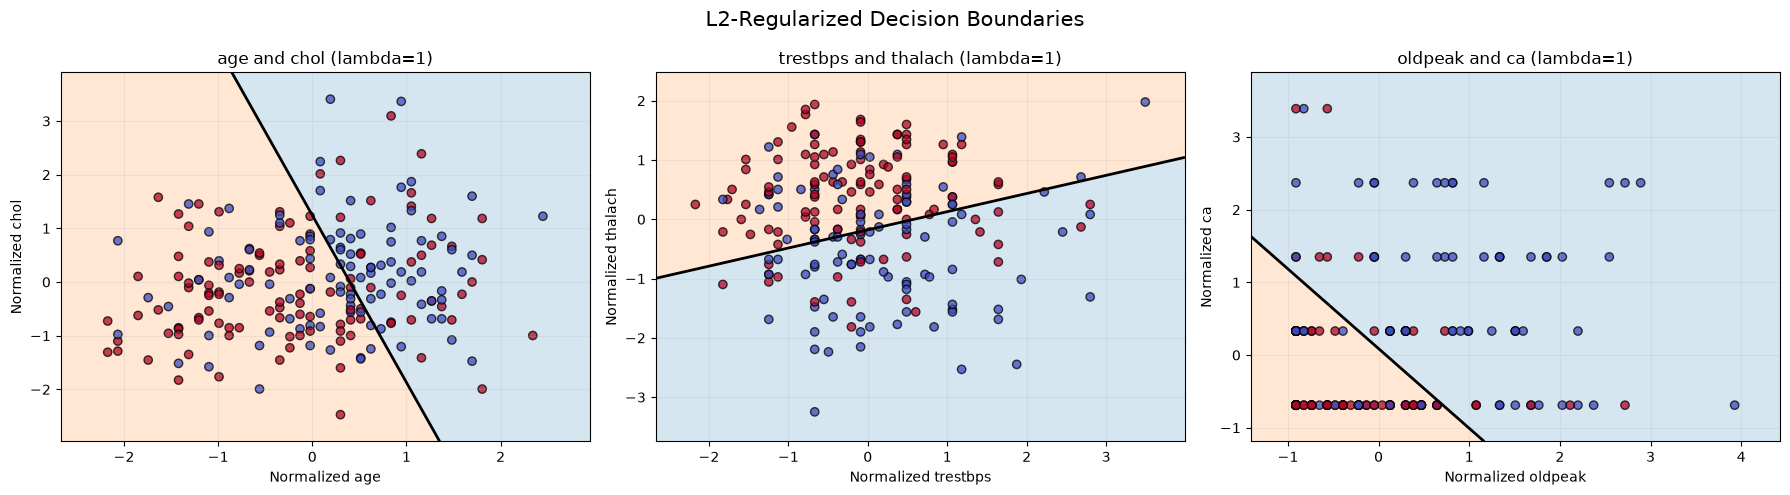

In [28]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for axis, (pair_name, model) in zip(axes, regularized_pair_models.items()):
    pair_indices = model["indices"]
    X_train_pair = X_train_normalized[:, pair_indices]
    first_grid = np.linspace(X_train_pair[:, 0].min() - 0.5, X_train_pair[:, 0].max() + 0.5, 200)
    second_grid = np.linspace(X_train_pair[:, 1].min() - 0.5, X_train_pair[:, 1].max() + 0.5, 200)
    grid_first, grid_second = np.meshgrid(first_grid, second_grid)
    grid_points = np.column_stack((grid_first.ravel(), grid_second.ravel()))
    surface = predict_probability(grid_points, model["w"], model["b"]).reshape(grid_first.shape)

    axis.contourf(grid_first, grid_second, surface, levels=[0, 0.5, 1], alpha=0.18, colors=["tab:blue", "tab:orange"])
    axis.contour(grid_first, grid_second, surface, levels=[0.5], colors="black", linewidths=2)
    axis.scatter(X_train_pair[:, 0], X_train_pair[:, 1], c=y_train, cmap="coolwarm", edgecolor="black", alpha=0.75)
    axis.set_title(f"{pair_name} (lambda={best_lambda})")
    axis.set_xlabel(f"Normalized {selected_features[pair_indices[0]]}")
    axis.set_ylabel(f"Normalized {selected_features[pair_indices[1]]}")
    axis.grid(alpha=0.2)

fig.suptitle("L2-Regularized Decision Boundaries", fontsize=15)
plt.tight_layout()
plt.show()

### Unregularized and Regularized Boundary Comparison

Compare both versions for the ST-depression and vessel-count pair using the same observations and plotting range.

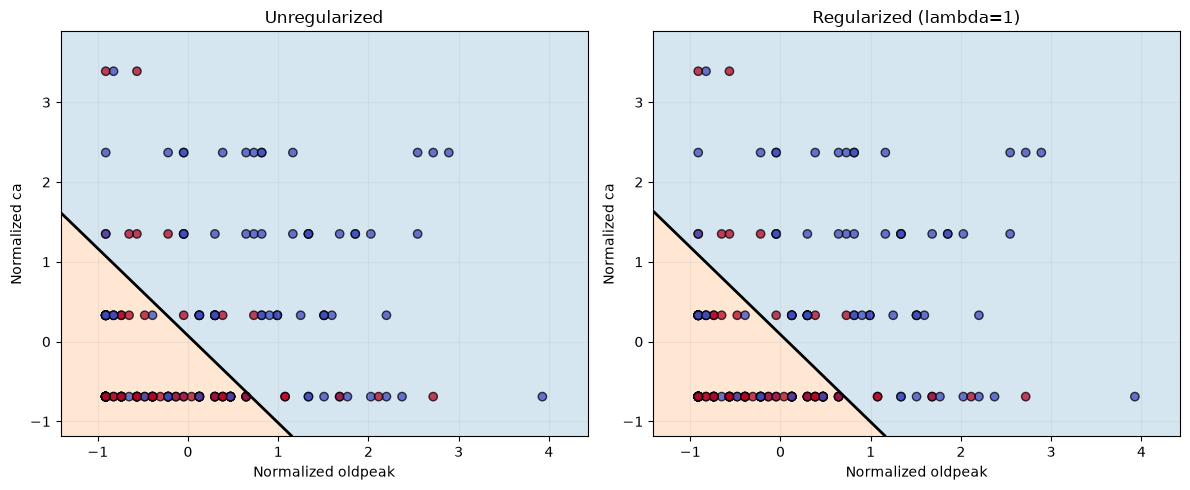

In [29]:
comparison_pair = "oldpeak and ca"
comparison_models = {
    "Unregularized": pair_models[comparison_pair],
    f"Regularized (lambda={best_lambda})": regularized_pair_models[comparison_pair],
}
pair_indices = pair_models[comparison_pair]["indices"]
X_train_pair = X_train_normalized[:, pair_indices]
first_grid = np.linspace(X_train_pair[:, 0].min() - 0.5, X_train_pair[:, 0].max() + 0.5, 200)
second_grid = np.linspace(X_train_pair[:, 1].min() - 0.5, X_train_pair[:, 1].max() + 0.5, 200)
grid_first, grid_second = np.meshgrid(first_grid, second_grid)
grid_points = np.column_stack((grid_first.ravel(), grid_second.ravel()))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for axis, (label, model) in zip(axes, comparison_models.items()):
    surface = predict_probability(grid_points, model["w"], model["b"]).reshape(grid_first.shape)
    axis.contourf(grid_first, grid_second, surface, levels=[0, 0.5, 1], alpha=0.18, colors=["tab:blue", "tab:orange"])
    axis.contour(grid_first, grid_second, surface, levels=[0.5], colors="black", linewidths=2)
    axis.scatter(X_train_pair[:, 0], X_train_pair[:, 1], c=y_train, cmap="coolwarm", edgecolor="black", alpha=0.75)
    axis.set_title(label)
    axis.set_xlabel("Normalized oldpeak")
    axis.set_ylabel("Normalized ca")
    axis.grid(alpha=0.2)

plt.tight_layout()
plt.show()

## 7. Prepare the SageMaker Execution

Export the exact normalized training and test partitions used locally. Upload this notebook, `heart.csv`, `sagemaker_train.csv`, and `sagemaker_test.csv` to SageMaker Studio, then run the notebook from top to bottom. Do not create or deploy an endpoint.

In [30]:
sagemaker_train_data = pd.DataFrame(X_train_normalized, columns=selected_features)
sagemaker_train_data["target"] = y_train
sagemaker_test_data = pd.DataFrame(X_test_normalized, columns=selected_features)
sagemaker_test_data["target"] = y_test

sagemaker_train_data.to_csv("sagemaker_train.csv", index=False)
sagemaker_test_data.to_csv("sagemaker_test.csv", index=False)

print("Exported sagemaker_train.csv:", sagemaker_train_data.shape)
print("Exported sagemaker_test.csv:", sagemaker_test_data.shape)
print("Selected lambda for SageMaker:", best_lambda)

Exported sagemaker_train.csv: (210, 7)
Exported sagemaker_test.csv: (92, 7)
Selected lambda for SageMaker: 1


### SageMaker Evidence — Pending Cloud Execution

The local files and model code are ready for SageMaker. After running them in AWS Academy, record the Studio image or Python version, instance information when visible, completion of training, and the test metrics. Capture at least three screenshots: the environment, successful training, and test metrics. The local and SageMaker results should match when the same data, seed, hyperparameters, and code are used; any difference must be reported rather than hidden.

### Regularization Discussion

All five tested values produce the same test predictions and therefore the same accuracy, precision, recall, and F1. However, increasing $\lambda$ steadily reduces the weight norm. The model with $\lambda=1$ has the lowest test binary cross-entropy, approximately 0.5322, and reduces the norm from approximately 1.5703 without regularization to 1.4967. It is selected for the instructional comparison because it adds measurable shrinkage without reducing the observed classification metrics.

The regularized and unregularized boundaries remain visually similar because the selected penalty changes coefficient magnitudes only modestly and does not change the test classifications. This result shows that regularization does not necessarily improve every metric; its direct role is to penalize large weights.

## 8. Final Insights

The six-feature logistic model converges smoothly and reaches test accuracy of approximately 0.739, precision of 0.732, recall of 0.820, and F1 of 0.774. Its recall is higher than its precision, so it finds most positive records at the cost of additional false positives. The two-feature experiments perform worse and show overlapping classes, indicating that the selected clinical information works better in combination than in isolated pairs.

L2 regularization with $\lambda=1$ shrinks the weights and slightly lowers test binary cross-entropy while leaving the 0.5-threshold classifications unchanged. These results describe this particular cleaned split; they do not demonstrate clinical validity. The dataset is small, contains a large number of exact duplicates in its downloaded form, and lacks the external validation, uncertainty analysis, and medical review required for clinical use.

The remaining task is to reproduce training and testing inside AWS Academy SageMaker, record its environment, preserve at least three screenshots, and compare its metrics with the local results. No endpoint is required or permitted for this assignment.